# Executive Sales Dashboard & Decision Report
### Olist Brazilian E-Commerce: from Data to Decision

**Author:** Atharva Shangarwar  |  **Dataset:** [Brazilian E-Commerce Public Dataset by Olist (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Business question:** *Is the business healthy, what could go wrong, and what should management do next?*

This notebook follows the flow **Data → Information → Insight → Decision → Action**:

1. Load the data
2. Clean the data
3. Merge the tables
4. Executive KPIs (Page 1 of the dashboard)
5. Sales and product analysis (Page 2)
6. Customer and risk analysis (Page 3)
7. Insights: Fact → Insight → Opportunity → Action
8. Export files for the Power BI / Tableau dashboard

> Setup (Google Colab): upload the Olist CSV files to the Colab file panel (`/content`), then run all cells.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})

OUT = Path("dashboard")
CHARTS = OUT / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.tight_layout()
    fig.savefig(CHARTS / f"{name}.png", dpi=150)
    plt.show()

## Step 1: Load the data
We use 6 of the 9 Olist files, read directly from the Colab `/content` folder. The others (sellers, geolocation, payments) are not needed for our business question.

In [2]:
date_cols = ["order_purchase_timestamp", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
orders    = pd.read_csv("/content/olist_orders_dataset.csv", parse_dates=date_cols)
items     = pd.read_csv("/content/olist_order_items_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")
products  = pd.read_csv("/content/olist_products_dataset.csv")
trans     = pd.read_csv("/content/product_category_name_translation.csv")
reviews   = pd.read_csv("/content/olist_order_reviews_dataset.csv")

summary = pd.DataFrame({
    "table": ["orders", "items", "customers", "products", "reviews"],
    "rows": [len(orders), len(items), len(customers), len(products), len(reviews)],
    "columns": [orders.shape[1], items.shape[1], customers.shape[1], products.shape[1], reviews.shape[1]],
    "missing_values": [d.isna().sum().sum() for d in (orders, items, customers, products, reviews)],
})
summary

,table,rows,columns,missing_values
0,orders,99441,8,4908
1,items,112650,7,0
2,customers,99441,5,0
3,products,32951,9,2448
4,reviews,99224,7,145903


In [3]:
print("Order status counts:")
print(orders["order_status"].value_counts())
print("\nDate range:", orders["order_purchase_timestamp"].min(), "to", orders["order_purchase_timestamp"].max())

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


## Step 2: Clean the data
Decisions made and why:
- **Delivered orders only**: cancelled or unavailable orders have no real revenue and no delivery date.
- **Remove duplicates** on `order_id`.
- **Window: Jan 2017 to Aug 2018**: 2016 has very few orders and the last months of 2018 are incomplete, which would distort trends and growth.
- **Delivery delay** = actual delivery date minus estimated delivery date. Positive means late.
- **One review score per order**: some orders have several reviews, so we average them.

In [4]:
n_before = len(orders)
orders = orders.drop_duplicates("order_id")
orders = orders[orders["order_status"] == "delivered"]
orders = orders.dropna(subset=["order_delivered_customer_date"])
orders = orders[(orders["order_purchase_timestamp"] >= "2017-01-01") &
                (orders["order_purchase_timestamp"] < "2018-09-01")].copy()

orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
orders["year"] = orders["order_purchase_timestamp"].dt.year
orders["delay_days"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days
orders["is_late"] = orders["delay_days"] > 0

review_per_order = reviews.groupby("order_id")["review_score"].mean().reset_index()

print(f"Orders before cleaning: {n_before:,}")
print(f"Orders after cleaning:  {len(orders):,}")

Orders before cleaning: 99,441
Orders after cleaning:  96,203


## Step 3: Merge the tables
`orders` is the center table. It connects to `items` and `reviews` through `order_id`, and to `customers` through `customer_id`. `items` connects to `products` through `product_id`.

> **Important:** `customer_id` changes with every order. To count real people we use **`customer_unique_id`**.

In [5]:
products = products.merge(trans, on="product_category_name", how="left")
products["category"] = products["product_category_name_english"].fillna("unknown")

lines = (items
         .merge(orders, on="order_id")
         .merge(customers[["customer_id", "customer_unique_id", "customer_state"]], on="customer_id")
         .merge(products[["product_id", "category"]], on="product_id", how="left"))
lines["category"] = lines["category"].fillna("unknown")

# One row per order
fact = (lines.groupby("order_id")
        .agg(customer=("customer_unique_id", "first"),
             state=("customer_state", "first"),
             month=("month", "first"),
             year=("year", "first"),
             purchase_date=("order_purchase_timestamp", "first"),
             delay_days=("delay_days", "first"),
             is_late=("is_late", "first"),
             revenue=("price", "sum"),
             freight=("freight_value", "sum"),
             n_items=("order_item_id", "count"))
        .reset_index()
        .merge(review_per_order, on="order_id", how="left"))

print("Line items:", f"{len(lines):,}", "| Orders:", f"{len(fact):,}")
fact.head()

Line items: 109,872 | Orders: 96,203


,order_id,customer,state,month,year,purchase_date,delay_days,is_late,revenue,freight,n_items,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,2017-09-01,2017,2017-09-13 08:59:02,-9,False,58.90,13.29,1,5.00
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,2017-04-01,2017,2017-04-26 10:53:06,-3,False,239.90,19.93,1,4.00
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,2018-01-01,2018,2018-01-14 14:33:31,-14,False,199.00,17.87,1,5.00
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,2018-08-01,2018,2018-08-08 10:00:35,-6,False,12.99,12.79,1,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,SP,2017-02-01,2017,2017-02-04 13:57:51,-16,False,199.90,18.14,1,5.00


## Step 4: Executive KPIs (Dashboard Page 1)
Olist has no Profit column, so **Revenue = item price (freight excluded)**.

**Above the fold:** Revenue, Growth %, Average Order Value. Fourth tile: On-time delivery %.

**Growth %** compares the same months (Jan to Aug) in 2018 vs 2017, so the comparison is fair.

In [6]:
revenue   = fact["revenue"].sum()
n_orders  = len(fact)
n_cust    = fact["customer"].nunique()
aov       = revenue / n_orders
on_time   = 1 - fact["is_late"].mean()
avg_score = fact["review_score"].mean()

same_months = fact[fact["purchase_date"].dt.month <= 8]
rev_by_year = same_months.groupby("year")["revenue"].sum()
growth = (rev_by_year[2018] / rev_by_year[2017] - 1) * 100

kpis = pd.DataFrame({
    "KPI": ["Revenue (R$)", "Orders", "Customers", "Average Order Value (R$)",
            "YoY Growth % (Jan-Aug)", "On-time delivery %", "Average review score"],
    "Value": [revenue, n_orders, n_cust, aov, growth, on_time * 100, avg_score],
})
kpis

,KPI,Value
0,Revenue (R$),"13,179,777.95"
1,Orders,"96,203.00"
2,Customers,"93,096.00"
3,Average Order Value (R$),137.00
4,YoY Growth % (Jan-Aug),141.11
5,On-time delivery %,93.21
6,Average review score,4.16


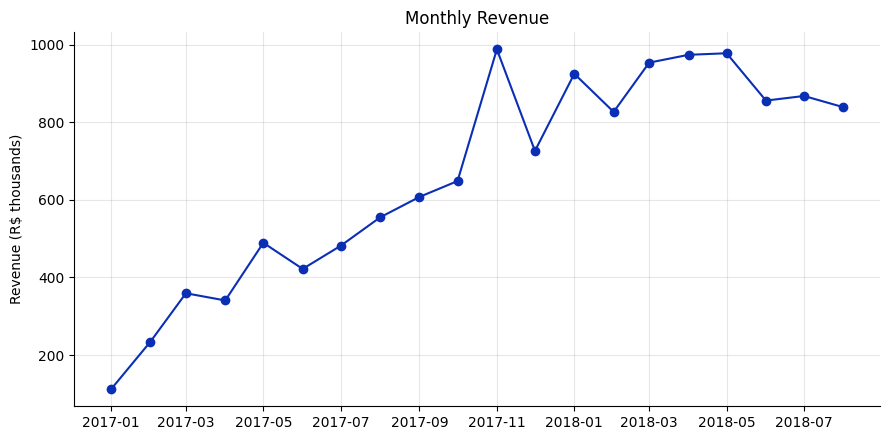

Peak month: Nov 2017 with R$ 987,648


In [7]:
monthly = (fact.groupby("month")
           .agg(revenue=("revenue", "sum"), orders=("order_id", "count"),
                customers=("customer", "nunique"),
                late_rate=("is_late", "mean"), avg_review=("review_score", "mean"))
           .reset_index())
monthly["aov"] = monthly["revenue"] / monthly["orders"]
monthly["mom_growth_pct"] = monthly["revenue"].pct_change() * 100

fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["revenue"] / 1e3, marker="o", color="#0A2FB5")
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue (R$ thousands)")
save(fig, "01_monthly_revenue")

peak = monthly.loc[monthly["revenue"].idxmax()]
print(f"Peak month: {peak['month']:%b %Y} with R$ {peak['revenue']:,.0f}")

## Step 5: Sales and product analysis (Dashboard Page 2)
Which categories and regions drive revenue (the *drivers*)?

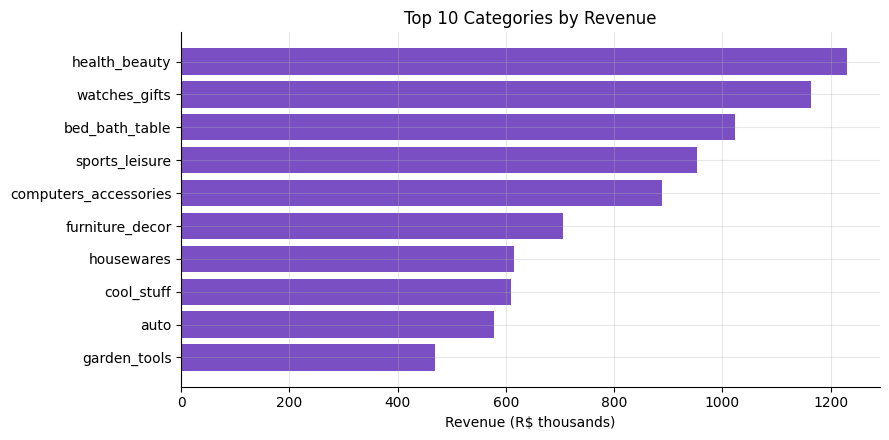

,category,revenue,orders,avg_price,share_pct,cum_share_pct
43,health_beauty,"1,229,557.50",8610,130.50,9.33,9.33
71,watches_gifts,"1,163,187.91",5489,198.73,8.83,18.15
7,bed_bath_table,"1,022,955.77",9267,93.46,7.76,25.92
65,sports_leisure,"952,661.40",7512,113.24,7.23,33.14
15,computers_accessories,"887,944.60",6517,116.36,6.74,39.88
39,furniture_decor,"706,237.17",6258,87.24,5.36,45.24
49,housewares,"614,341.62",5734,90.57,4.66,49.90
20,cool_stuff,"609,158.00",3552,164.15,4.62,54.52
5,auto,"577,721.09",3801,139.85,4.38,58.91
42,garden_tools,"469,135.40",3443,110.05,3.56,62.47


In [8]:
category = (lines.groupby("category")
            .agg(revenue=("price", "sum"), orders=("order_id", "nunique"), avg_price=("price", "mean"))
            .reset_index().sort_values("revenue", ascending=False))
category["share_pct"] = category["revenue"] / category["revenue"].sum() * 100
category["cum_share_pct"] = category["share_pct"].cumsum()

top10 = category.head(10).iloc[::-1]
fig, ax = plt.subplots()
ax.barh(top10["category"], top10["revenue"] / 1e3, color="#7B4FC4")
ax.set_title("Top 10 Categories by Revenue")
ax.set_xlabel("Revenue (R$ thousands)")
save(fig, "02_top_categories")
category.head(10)

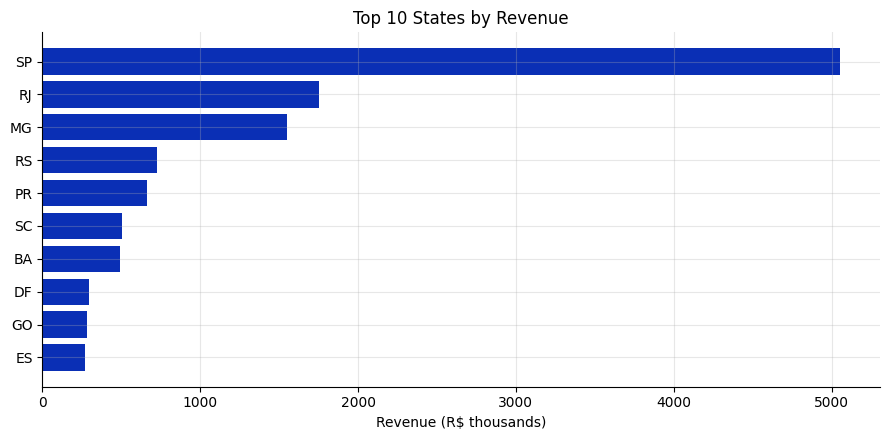

,state,revenue,orders,customers,late_rate,avg_review,avg_delay_days,share_pct
25,SP,"5,054,516.95",40399,39058,0.04,4.25,-11.02,38.35
18,RJ,"1,751,433.85",12310,11879,0.12,3.97,-11.68,13.29
10,MG,"1,548,206.88",11319,10969,0.05,4.19,-13.17,11.75
22,RS,"726,194.92",5327,5150,0.06,4.19,-13.84,5.51
17,PR,"664,048.00",4903,4750,0.04,4.24,-13.22,5.04
23,SC,"504,774.07",3537,3441,0.08,4.13,-11.44,3.83
4,BA,"493,339.26",3253,3155,0.12,3.93,-10.77,3.74
6,DF,"295,454.64",2074,2013,0.06,4.14,-11.98,2.24
8,GO,"281,932.21",1950,1889,0.07,4.10,-12.06,2.14
7,ES,"267,783.66",1992,1925,0.11,4.08,-10.45,2.03


In [9]:
state = (fact.groupby("state")
         .agg(revenue=("revenue", "sum"), orders=("order_id", "count"),
              customers=("customer", "nunique"),
              late_rate=("is_late", "mean"), avg_review=("review_score", "mean"),
              avg_delay_days=("delay_days", "mean"))
         .reset_index().sort_values("revenue", ascending=False))
state["share_pct"] = state["revenue"] / state["revenue"].sum() * 100

top_states = state.head(10).iloc[::-1]
fig, ax = plt.subplots()
ax.barh(top_states["state"], top_states["revenue"] / 1e3, color="#0A2FB5")
ax.set_title("Top 10 States by Revenue")
ax.set_xlabel("Revenue (R$ thousands)")
save(fig, "03_top_states")
state.head(10)

## Step 6: Customer and risk analysis (Dashboard Page 3)
Two risks are checked:
1. **Delivery risk:** do late deliveries lead to bad reviews, and where is the problem worst?
2. **Customer risk:** how many customers come back, and are high-value customers going inactive (180+ days)?

Most Olist customers order only once, so "churn" here means high-value customers who have not returned in 180+ days.

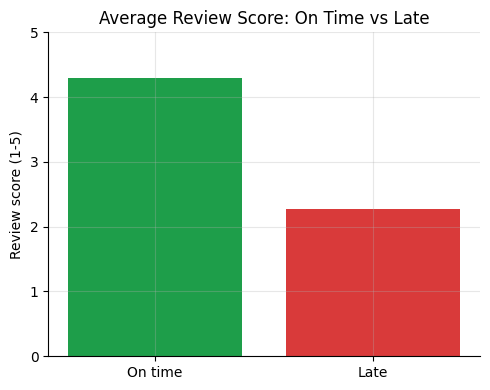

On-time avg review: 4.29 | Late avg review: 2.27
Bad reviews (1-2 stars): on time 9.2% | late 60.9%


In [10]:
# --- Delivery risk ---
score_by_late = fact.groupby("is_late")["review_score"].mean()
bad_by_late = fact.assign(bad=fact["review_score"] <= 2).groupby("is_late")["bad"].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["On time", "Late"], [score_by_late[False], score_by_late[True]], color=["#1E9E4A", "#D93A3A"])
ax.set_ylim(0, 5)
ax.set_title("Average Review Score: On Time vs Late")
ax.set_ylabel("Review score (1-5)")
save(fig, "04_review_late_vs_ontime")

print(f"On-time avg review: {score_by_late[False]:.2f} | Late avg review: {score_by_late[True]:.2f}")
print(f"Bad reviews (1-2 stars): on time {bad_by_late[False]:.1f}% | late {bad_by_late[True]:.1f}%")

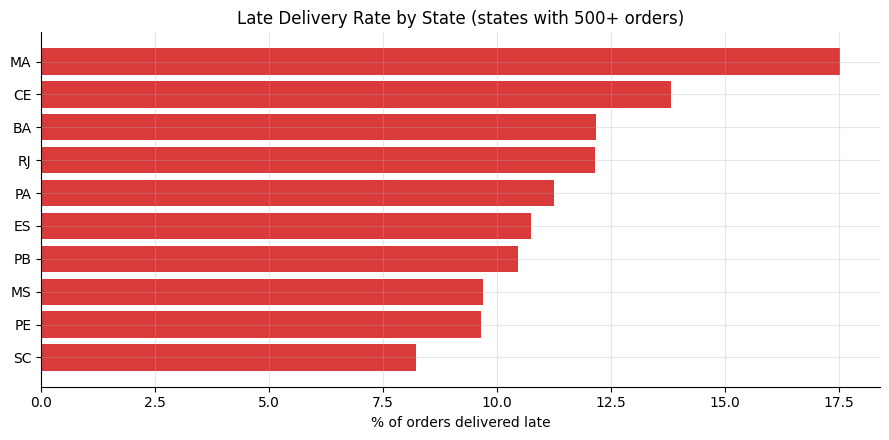

,state,orders,late_rate,avg_review,avg_delay_days
9,MA,713,0.18,3.83,-9.42
5,CE,1273,0.14,3.94,-10.63
4,BA,3253,0.12,3.93,-10.77
18,RJ,12310,0.12,3.97,-11.68
13,PA,942,0.11,3.91,-13.96
7,ES,1992,0.11,4.08,-10.45
14,PB,516,0.10,4.07,-13.23
11,MS,701,0.10,4.16,-11.05
15,PE,1587,0.10,4.08,-13.17
23,SC,3537,0.08,4.13,-11.44


In [11]:
big_states = state[state["orders"] >= 500].sort_values("late_rate", ascending=False).head(10).iloc[::-1]
fig, ax = plt.subplots()
ax.barh(big_states["state"], big_states["late_rate"] * 100, color="#D93A3A")
ax.set_title("Late Delivery Rate by State (states with 500+ orders)")
ax.set_xlabel("% of orders delivered late")
save(fig, "05_late_rate_by_state")
big_states.iloc[::-1][["state", "orders", "late_rate", "avg_review", "avg_delay_days"]]

In [12]:
# --- Customer risk ---
snapshot = fact["purchase_date"].max()
cust = (fact.groupby("customer")
        .agg(orders=("order_id", "count"), revenue=("revenue", "sum"),
             last_order=("purchase_date", "max"), avg_review=("review_score", "mean"))
        .reset_index())
cust["days_since_last"] = (snapshot - cust["last_order"]).dt.days
cust["is_repeat"] = cust["orders"] > 1
cust["high_value"] = cust["revenue"] >= cust["revenue"].quantile(0.80)
cust["inactive_180"] = cust["days_since_last"] > 180
cust["at_risk_high_value"] = cust["high_value"] & cust["inactive_180"]

repeat_rate = cust["is_repeat"].mean() * 100
n_high = int(cust["high_value"].sum())
n_at_risk = int(cust["at_risk_high_value"].sum())
risk_revenue = cust.loc[cust["at_risk_high_value"], "revenue"].sum()

print(f"Repeat customer rate: {repeat_rate:.1f}%")
print(f"High-value customers (top 20% by spend): {n_high:,}")
print(f"High-value AND inactive 180+ days: {n_at_risk:,} ({n_at_risk / n_high:.0%} of high-value)")
print(f"Revenue tied to these at-risk customers: R$ {risk_revenue:,.0f}")

# Does a late FIRST delivery reduce repeat purchases?
# (We use the first order only. Using "any late order" would be biased, because customers
#  with more orders have more chances to get a late one.)
first = (fact.sort_values("purchase_date").groupby("customer")["is_late"].first()
         .rename("first_late").reset_index())
cust = cust.merge(first, on="customer")
repeat_by_first = cust.groupby("first_late")["is_repeat"].mean() * 100
print(f"\nRepeat rate if first order was on time: {repeat_by_first[False]:.2f}% | first order late: {repeat_by_first[True]:.2f}%")

Repeat customer rate: 3.0%
High-value customers (top 20% by spend): 18,726
High-value AND inactive 180+ days: 10,912 (58% of high-value)
Revenue tied to these at-risk customers: R$ 4,311,606

Repeat rate if first order was on time: 3.03% | first order late: 2.58%


## Step 7: Insights (Fact → Insight → Opportunity → Action)
The cell below builds the summary sentences from the real numbers computed above, so nothing is typed by hand.

In [13]:
top_state = state.iloc[0]
top_cat = category.iloc[0]
worst_state = state[state["orders"] >= 500].sort_values("late_rate", ascending=False).iloc[0]

insights = [
    ("Growth",
     f"Revenue {'grew' if growth >= 0 else 'fell'} {abs(growth):.1f}% year over year (Jan-Aug 2018 vs 2017).",
     f"Top state {top_state['state']} generates {top_state['share_pct']:.1f}% of revenue; top category '{top_cat['category']}' is {top_cat['share_pct']:.1f}%.",
     "Growth depends on a few regions and categories.",
     "Protect and expand the top state and category, and test 1-2 growth categories."),
    ("Delivery risk",
     f"Late orders average {score_by_late[True]:.2f} stars vs {score_by_late[False]:.2f} for on-time orders; {(1 - on_time) * 100:.1f}% of orders arrive late.",
     f"{worst_state['state']} has the highest late rate ({worst_state['late_rate'] * 100:.1f}%) among states with 500+ orders.",
     "Fixing delivery in the worst states can lift reviews.",
     f"Work with carriers and fix delivery estimates first in {worst_state['state']}."),
    ("Customer risk",
     f"{repeat_rate:.1f}% of customers ordered more than once.",
     f"{n_at_risk:,} high-value customers have not ordered for 180+ days (R$ {risk_revenue:,.0f} in past spend); most are one-time buyers.",
     "Bringing back even a small share of these customers is cheap growth.",
     "Launch a targeted win-back offer for inactive high-value customers."),
]

for name, fact_, insight, opp, action in insights:
    print(f"--- {name} ---")
    print("FACT:        ", fact_)
    print("INSIGHT:     ", insight)
    print("OPPORTUNITY: ", opp)
    print("ACTION:      ", action)
    print()

--- Growth ---
FACT:         Revenue grew 141.1% year over year (Jan-Aug 2018 vs 2017).
INSIGHT:      Top state SP generates 38.4% of revenue; top category 'health_beauty' is 9.3%.
OPPORTUNITY:  Growth depends on a few regions and categories.
ACTION:       Protect and expand the top state and category, and test 1-2 growth categories.

--- Delivery risk ---
FACT:         Late orders average 2.27 stars vs 4.29 for on-time orders; 6.8% of orders arrive late.
INSIGHT:      MA has the highest late rate (17.5%) among states with 500+ orders.
OPPORTUNITY:  Fixing delivery in the worst states can lift reviews.
ACTION:       Work with carriers and fix delivery estimates first in MA.

--- Customer risk ---
FACT:         3.0% of customers ordered more than once.
INSIGHT:      10,912 high-value customers have not ordered for 180+ days (R$ 4,311,606 in past spend); most are one-time buyers.
OPPORTUNITY:  Bringing back even a small share of these customers is cheap growth.
ACTION:       Launch a tar

## Step 8: Export data for the dashboard
These CSV files feed the 3 dashboard pages in Power BI or Tableau Public:
- **Page 1, Executive Overview:** `kpis.csv`, `monthly.csv`
- **Page 2, Sales and Product:** `category.csv`, `state.csv`
- **Page 3, Customer and Risk:** `customers.csv`, `state.csv` (late rate), `fact_orders.csv`

In [14]:
kpis.to_csv(OUT / "kpis.csv", index=False)
monthly.to_csv(OUT / "monthly.csv", index=False)
category.to_csv(OUT / "category.csv", index=False)
state.to_csv(OUT / "state.csv", index=False)
cust.to_csv(OUT / "customers.csv", index=False)
fact.to_csv(OUT / "fact_orders.csv", index=False)
print("Saved:", sorted(p.name for p in OUT.glob("*.csv")))
print("Charts:", sorted(p.name for p in CHARTS.glob("*.png")))

Saved: ['category.csv', 'customers.csv', 'fact_orders.csv', 'kpis.csv', 'monthly.csv', 'state.csv']
Charts: ['01_monthly_revenue.png', '02_top_categories.png', '03_top_states.png', '04_review_late_vs_ontime.png', '05_late_rate_by_state.png']


## Conclusion
- Revenue growth (see the KPI table) is concentrated in a few states and categories.
- Late deliveries lower customer reviews, and the problem is worse in certain states.
- The repeat customer rate is low, so win-back offers for high-value customers are a low-cost opportunity.
- **Limitations:** no Profit or cost data (Revenue is used instead); "churn" is approximated by 180+ days of inactivity; the data covers 2017 to 2018 only.
- **Next steps:** add profit data if available, build a repeat-purchase prediction model, and track delivery KPIs monthly.